# Radio-burst inference: one timestamp in, a forecast out

Notebooks 1 and 2 train models. This one **uses** one: you give it a time, it gives back the burst probability and, when it predicts a burst, the predicted radio spectrogram — plotted against what was actually observed, whenever the catalog has that window.

**This runs the linear baseline from notebook 1.** It is two `nn.Linear` layers, so the whole notebook runs on CPU in seconds. Swapping in the fine-tuned Surya model is two cells, both marked **swap for Surya** below.

**What the answer means.** The config sets `ds_forecast_horizon: 3h` and the catalog's windows are one hour long, so a Surya frame at time `t` forecasts a burst in the window **`[t+3h, t+4h]`**, and the predicted spectrogram covers those 60 minutes.

Three details make inference different from training, and each has a helper in `inference.py`:

1. Surya frames sit on a 12-minute grid and some are missing, so your timestamp is snapped and checked — nothing is interpolated.
2. `HelioNetCDFDataset` reads an index CSV, so a single frame becomes a one-row index.
3. A checkpoint is not a model: it has to be rebuilt and loaded strictly.

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the CUDA visible device you put here is the one assigned to your team and your machine.

The baseline path below never touches the GPU — it loads on CPU — so this only matters once you swap in Surya.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LogNorm
from torch.utils.data import DataLoader

# Append base path. It gives the notebook access to the workshop_infrastructure folder.
sys.path.append("../../")

from downstream_apps.radioburst.configs import load_radioburst_config
from downstream_apps.radioburst.inference import (
    build_single_frame_dataset,
    find_catalog_window,
    latest_checkpoint,
    load_baseline_model,
    predict_baseline,
    resolve_frame,
    single_frame_index,
    spectrogram_axes,
)
from downstream_apps.radioburst.spectra_transform import read_spectra_file
from workshop_infrastructure.assets import ensure_assets
from workshop_infrastructure.utils import build_scalers

torch.set_float32_matmul_precision("medium")

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Load configuration

The same config the model was trained with. That matters more here than anywhere else: the model is rebuilt from the checkpoint and fed by a dataset built from this config, so a config that has drifted from the run produces inputs the model never saw.

In [3]:
cfg = load_radioburst_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")

# Only the scalers: the baseline has no backbone, so the 1.8 GB pretrained weights are
# not needed. (They are not needed for Surya inference either — a fine-tuned checkpoint
# already contains every backbone tensor.)
ensure_assets(cfg, which=["scalers"])
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

Loaded config for job: radio_burst_forecasting
Loaded scalers for 13 channels.


## The two things you choose

A **timestamp** and a **checkpoint**. Everything below follows from them.

The timestamp is looked up in the full Surya index (2010-05-13 to 2024-12-31). For an answer you can judge, pick a time from the **validation split**, which the model was scored on but never trained on:

| Timestamp | Forecast window | What actually happened |
|---|---|---|
| `2014-01-21 02:00` | 2014-01-21 05:00–06:00 | burst |
| `2019-01-29 13:00` | 2019-01-29 16:00–17:00 | quiet |

`cfg.output.ckpt_dir` is relative to the working directory, which is this folder — the same place notebooks 1 and 2 write to.

In [4]:
timestamp = "2014-01-21 02:00"          # <-- the time you are asking about
surya_index_path = "../../data/indices/surya_aws_s3_full_index.csv"

# The newest baseline checkpoint.  <-- swap for Surya: pattern="finetune-*.ckpt"
ckpt_path = latest_checkpoint(cfg.output.ckpt_dir, pattern="baseline-*.ckpt")
print(f"Checkpoint: {ckpt_path}")

Checkpoint: checkpoints/baseline-epoch=02-val_loss_bce=0.6954.ckpt


## Find the frame

Surya observations are 12 minutes apart and some are missing, so your timestamp is rounded to the nearest grid point and that frame is required to be present. A missing frame is a missing observation: substituting a neighbour would quietly change what the prediction is about, so `resolve_frame` raises instead and names the nearest usable frames.

In [5]:
frame = resolve_frame(timestamp, surya_index_path)
window_start = frame["timestep"] + pd.Timedelta(cfg.data.ds_forecast_horizon)

print(f"Requested:       {timestamp}")
print(f"Using frame:     {frame['timestep']}  ({frame['path']})")
print(f"Forecast window: {window_start} to {window_start + pd.Timedelta('1h')}")

Requested:       2014-01-21 02:00
Using frame:     2014-01-21 02:00:00  (s3://nasa-surya-bench/2014/01/20140121_0200.nc)
Forecast window: 2014-01-21 05:00:00 to 2014-01-21 06:00:00


## Load that one frame

`HelioNetCDFDataset` is driven by an index file, so one frame becomes a one-row index and a dataset of length 1. Plain `HelioNetCDFDataset`, not `RadioBurstDSDataset`: the model reads only the image stack, and there is no label to align here — which is exactly why this works for any time, not just catalogued burst windows.

The first run for a given frame downloads ~600 MB of NetCDF into `s3_cache_dir`; later runs on the same frame read it from there.

In [6]:
with single_frame_index(frame) as index_path:
    dataset = build_single_frame_dataset(cfg, index_path, scalers=scalers)
    # Materialize the batch inside the block: the index file is removed on exit.
    batch = next(iter(DataLoader(dataset, batch_size=1)))

print({k: tuple(v.shape) if torch.is_tensor(v) else v for k, v in batch.items()})

{'ts': (1, 13, 1, 4096, 4096), 'time_delta_input': (1, 1)}


## Rebuild the model and load the weights

A Lightning checkpoint holds weights, not a model, and `RadioBurstLightningModule` never calls `save_hyperparameters()` — so `load_from_checkpoint()` has nothing to rebuild from. `load_baseline_model()` instead reads the model's shape out of the checkpoint itself: `classifier.weight` gives the input width, and the `normalized_template` buffer carries the median spectrogram, so the reload does not depend on the catalog's template CSV still holding what it held during training.

The load is **strict**: every tensor must match. That is what turns "this checkpoint is from a different model" into an error instead of a model that is half randomly initialized and still happily predicts.

**Swap for Surya:** `load_finetuned_burst_model(cfg, ckpt_path)`, which does the same thing for the fine-tuned model — rebuilding the architecture from `cfg.model`, re-applying LoRA, and reading the head's geometry from the checkpoint.

In [7]:
model = load_baseline_model(cfg, ckpt_path)   # <-- swap for Surya: load_finetuned_burst_model

device = next(model.parameters()).device
print(f"Model on {device}, eval mode: {not model.training}")
print(f"Spectrogram template: {tuple(model.normalized_template.shape)} (time steps, frequency bins)")

Model on cpu, eval mode: True
Spectrogram template: (120, 288) (time steps, frequency bins)


## Classify

The baseline collapses the image stack to a per-channel mean and standard deviation, then runs two linear layers: one for the burst probability, one for the amplitude. `predict_baseline` handles the step that is easy to miss — the baseline reads its input in **signum-log** space, so the dataset's z-score is undone first with `destandardize_channels()`, exactly as `preprocess_fn` did during training.

The decision threshold is 0.5, the default `torchmetrics.F1Score(task="binary")` used while training, so this number is comparable with the F1 in your training logs. It is a default, not a tuned operating point.

**Swap for Surya:** `predict(model, batch)` — the Surya head returns a logit, which `predict` squashes for you.

In [8]:
BURST_THRESHOLD = 0.5

result = predict_baseline(model, batch, cfg, scalers)   # <-- swap for Surya: predict(model, batch)
burst_probability = float(result["burst_probability"][0])
is_burst = burst_probability >= BURST_THRESHOLD

print(f"Burst probability: {burst_probability:.3f}")
print(f"Prediction:        {'BURST' if is_burst else 'no burst'} "
      f"in {window_start} to {window_start + pd.Timedelta('1h')}")

Burst probability: 0.460
Prediction:        no burst in 2014-01-21 05:00:00 to 2014-01-21 06:00:00


## What actually happened

`find_catalog_window()` looks up the window this forecast would have been scored against, using the same rule the dataset uses at training time: the earliest catalog window at or after `window_start`, within `ds_time_tolerance`. Reusing that rule is the point — the notebook should never present a "truth" that training itself would not have paired with this frame.

The lookup runs whatever the model predicted. Observed data is not the model's to withhold, and gating it on the prediction would hide the case most worth seeing: the model says quiet and the catalog says burst.

Most timestamps have no match at all — the catalog holds 170 windows across 14 years — and that is not an error, just a forecast nobody can check.

In [9]:
catalog_row = find_catalog_window(cfg, window_start)

if catalog_row is None:
    observed_flux = None
    print("No catalogued window near this forecast — nothing to compare against.")
else:
    observed_flux = read_spectra_file(
        cfg.data.ds_radioburst_folder_path, catalog_row[cfg.data.ds_spectra_column]
    )
    observed_label = "BURST" if catalog_row["burst"] else "quiet"
    print(f"Catalog window:  {catalog_row[cfg.data.ds_time_column]} — {observed_label}")
    print(f"Observed spectrogram: {observed_flux.shape}, "
          f"flux {np.nanmin(observed_flux):.2e} to {np.nanmax(observed_flux):.2e}")
    print(f"Classification {'matches' if is_burst == bool(catalog_row['burst']) else 'DOES NOT match'}"
          " the catalog — one sample, which says nothing about the model in general.")

Catalog window:  2014-01-21 05:00:00 — BURST
Observed spectrogram: (120, 288), flux 1.88e-15 to 6.54e-11
Classification DOES NOT match the catalog — one sample, which says nothing about the model in general.


## The predicted spectrogram

Only when a burst is predicted. The amplitude regressor is trained against burst windows, so on a quiet window its output was never optimized against anything — showing it would be inventing a burst.

**The baseline predicts flux directly**, so there is nothing to invert: it multiplies a fixed median-burst template by the amplitude it regressed, in the same raw units as the observed files. Be clear-eyed about what that means — **every predicted spectrogram has the same shape**, and only its brightness changes. The structure you see in the left panel below is the template's, not a finding.

**A units caveat, measured.** The catalog's `peak_amp` column runs 1.26–4.03, while the observed spectrogram files hold flux around `1e-15`–`1e-11`. `TwoStageBurstModel` multiplies a template normalized to a peak of 1 by that `peak_amp`, so its "spectra" come out on the `peak_amp` scale, **not** in the flux units of the observed files — roughly ten orders of magnitude apart. The two panels below are therefore not directly comparable until that is reconciled (either the catalog's `peak_amp` is in different units than the spectra files, or the template needs rescaling to flux). The cell prints a warning whenever the two peaks are more than 100x apart, so this cannot pass unnoticed.

**Swap for Surya:** the fine-tuned head predicts in the normalized space its targets were built in, so there you need `load_spectra_normalizer(cfg, ckpt_path).inverse(...)` before plotting.

In [10]:
if is_burst:
    predicted_flux = result["spectra"][0]          # (T, F), already raw flux
    print(f"Predicted amplitude:  {result['peak_amp'][0]:.2e}")
    print(f"Predicted spectrogram: {predicted_flux.shape}, "
          f"flux {predicted_flux.min():.2e} to {predicted_flux.max():.2e}")
    if observed_flux is not None:
        ratio = predicted_flux.max() / np.nanmax(observed_flux)
        print(f"Peak: predicted {predicted_flux.max():.2e} vs "
              f"observed {np.nanmax(observed_flux):.2e}  ({ratio:.2g}x)")
        if not 0.01 < ratio < 100:
            print("  WARNING: these differ by orders of magnitude. The baseline's spectra are\n"
                  "  peak_amp x a unit-peak template, and the catalog's peak_amp (1.26-4.03) is not\n"
                  "  on the same scale as the observed flux files (1e-15 to 1e-11). Treat the panels\n"
                  "  as differently scaled until that is reconciled.")
else:
    predicted_flux = None
    print(f"No burst predicted (p={burst_probability:.3f}) — no predicted spectrogram.")

No burst predicted (p=0.460) — no predicted spectrogram.


### Plotting it

Whichever panels exist get drawn: predicted when the model called a burst, observed when the catalog has the window, both when both. They share **one logarithmic color scale and one colorbar** — on separate scales a badly calibrated prediction would look just as convincing as a good one, which is the opposite of what a comparison is for.

Two things about the frequency axis. The 288 bins are **not evenly spaced** — they come from two receivers, RAD1 (20 kHz–1.04 MHz) and RAD2 (1.08–13.8 MHz) — and RAD2 pairs bins, so 38 frequencies appear twice. Plotting against frequency directly would need cell edges that duplicated frequencies cannot provide, so the rows are drawn in bin order with the frequency on the tick labels, and a line marks where RAD1 hands over to RAD2.

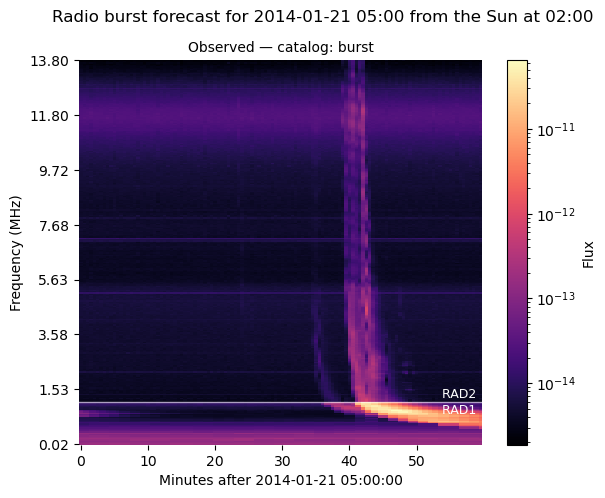

In [11]:
def plot_spectrogram(ax, spectra, minutes, frequencies_mhz, norm, title):
    """Draw one (T, F) spectrogram in bin order, with frequencies on the tick labels."""
    mesh = ax.pcolormesh(minutes, np.arange(len(frequencies_mhz)), spectra.T,
                         norm=norm, cmap="magma", shading="nearest")
    n_rad1 = int((frequencies_mhz < 1.05).sum())      # RAD1 occupies the first bins
    ax.axhline(n_rad1 - 0.5, color="white", linewidth=1, alpha=0.6)
    ax.text(minutes[-1], n_rad1 - 1.5, "RAD1 ", color="white", ha="right", va="top", fontsize=9)
    ax.text(minutes[-1], n_rad1 + 0.5, "RAD2 ", color="white", ha="right", va="bottom", fontsize=9)

    ticks = np.linspace(0, len(frequencies_mhz) - 1, 8).astype(int)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{frequencies_mhz[i]:.2f}" for i in ticks])
    ax.set_xlabel(f"Minutes after {window_start}")
    ax.set_title(title, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return mesh


panels = [("Predicted", predicted_flux), ("Observed", observed_flux)]
panels = [(label, spectra) for label, spectra in panels if spectra is not None]

if not panels:
    print(f"Nothing to plot: no burst predicted (p={burst_probability:.3f}) "
          "and no catalogued window to show.")
else:
    minutes, frequencies_mhz = spectrogram_axes(
        Path(cfg.data.ds_radioburst_folder_path) / cfg.data.ds_spectra_template_file
    )
    # One scale across every panel, so the two are directly comparable.
    finite = np.concatenate([s[np.isfinite(s)].ravel() for _, s in panels])
    norm = LogNorm(vmin=max(finite.min(), 1e-16), vmax=finite.max())

    fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 5), squeeze=False)
    for ax, (label, spectra) in zip(axes[0], panels):
        subtitle = (f"model: p = {burst_probability:.2f}" if label == "Predicted"
                    else f"catalog: {'burst' if catalog_row['burst'] else 'quiet'}")
        mesh = plot_spectrogram(ax, spectra, minutes, frequencies_mhz, norm,
                                f"{label} — {subtitle}")
    axes[0][0].set_ylabel("Frequency (MHz)")
    fig.suptitle(f"Radio burst forecast for {window_start:%Y-%m-%d %H:%M} "
                 f"from the Sun at {frame['timestep']:%H:%M}", fontsize=12)
    fig.colorbar(mesh, ax=axes[0].tolist(), label="Flux")
    plt.show()

## Before you believe any of this

The pipeline is finished; the science is not. Read these before quoting a number from this notebook.

- **This is the baseline, and it is barely trained.** The catalog holds 170 windows (85 burst, 85 quiet), which matched 116 training and 7 validation windows. In the latest baseline run the validation F1 was **0.0** and `val_loss_bce` sat at 0.6986 (that term is logged as `val_loss_burst_bce` since the loss weights were split out) — that is a model predicting essentially one class. Read the plot as a demonstration of the pipeline, not as a forecast.
- **The predicted shape is fixed.** The baseline scales one median template, so the only thing it predicts about the spectrogram is its brightness.
- **Ground truth exists for 170 windows only.** Any other timestamp gives a prediction nobody can check.
- **The threshold is a default,** not an operating point chosen from a precision/recall curve.
- **One frame, no history.** `time_delta_input_minutes: [0]` means the model sees a single image stack, not a sequence.

## Conclusion

Dataset, baseline, fine-tuning and now prediction: the loop is closed. The next step is to swap the three marked cells over to the fine-tuned Surya model and see whether it beats a scaled template — and to grow the catalog, because with 7 validation windows no amount of modelling work can be measured.